<a href="https://colab.research.google.com/github/jaykumargaikwad9075-dot/Machine-Learning/blob/main/Assignment_No_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported")


Libraries imported


In [2]:
wine = load_wine(as_frame=True)
df = wine.frame.copy()
df.rename(columns={'target': 'class'}, inplace=True)
df['class'] = df['class'].apply(lambda i: wine.target_names[i])

df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [3]:
print("Shape:", df.shape)
print("Classes:", df['class'].unique())

df.describe()


Shape: (178, 14)
Classes: [np.str_('class_0') np.str_('class_1') np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [4]:
X = df[['alcohol', 'malic_acid']]
y = df['class']

X.head()


,alcohol,malic_acid
0,14.23,1.71
1,13.20,1.78
2,13.16,2.36
3,14.37,1.95
4,13.24,2.59


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)


Training size: (124, 2)
Testing size: (54, 2)


In [6]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

print("Model trained")


Model trained


In [7]:
y_pred = svm.predict(X_test)
list(y_pred)[:10]


[np.str_('class_2'),
 np.str_('class_2'),
 np.str_('class_2'),
 np.str_('class_0'),
 np.str_('class_1'),
 np.str_('class_0'),
 np.str_('class_1'),
 np.str_('class_2'),
 np.str_('class_1'),
 np.str_('class_0')]

In [8]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

results['Status'] = results.apply(
    lambda r: 'Correct' if r.Actual == r.Predicted else 'Wrong',
    axis=1
)

results.head(20)


,Actual,Predicted,Status
0,class_0,class_2,Wrong
1,class_0,class_2,Wrong
2,class_2,class_2,Correct
3,class_0,class_0,Correct
4,class_1,class_1,Correct
5,class_0,class_0,Correct
6,class_1,class_1,Correct
7,class_2,class_2,Correct
8,class_1,class_1,Correct
9,class_2,class_0,Wrong


In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n",
      classification_report(y_test, y_pred))


Accuracy: 0.7407407407407407

Confusion Matrix:
 [[16  0  3]
 [ 3 16  2]
 [ 4  2  8]]

Classification Report:
               precision    recall  f1-score   support

     class_0       0.70      0.84      0.76        19
     class_1       0.89      0.76      0.82        21
     class_2       0.62      0.57      0.59        14

    accuracy                           0.74        54
   macro avg       0.73      0.73      0.73        54
weighted avg       0.75      0.74      0.74        54



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


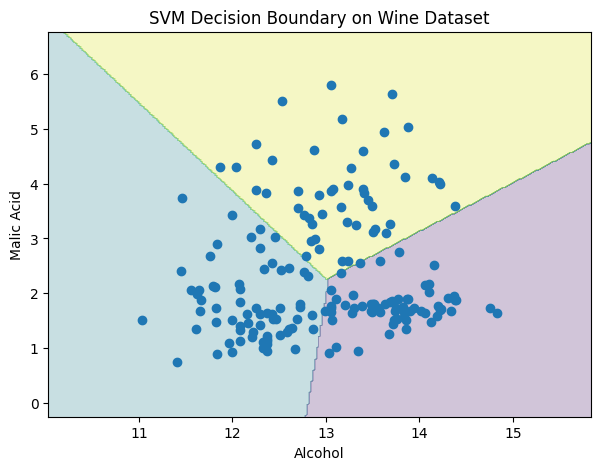

In [11]:
x_min, x_max = X.iloc[:,0].min()-1, X.iloc[:,0].max()+1
y_min, y_max = X.iloc[:,1].min()-1, X.iloc[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])

# Map string labels to numerical values for plotting
class_labels = svm.classes_
class_to_int = {label: i for i, label in enumerate(class_labels)}
Z_numeric = np.array([class_to_int[label] for label in Z.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z_numeric, alpha=0.25)
plt.scatter(X.iloc[:,0], X.iloc[:,1])
plt.xlabel("Alcohol")
plt.ylabel("Malic Acid")
plt.title("SVM Decision Boundary on Wine Dataset")
plt.show()